<a href="https://colab.research.google.com/github/NoT-Serna/Juan_Serna_FlyRank/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The action queue uses the validated model output into a human-review prioritization list. Each content item is ranked by its predicted probability of requiring review, with higher-probability items appearing first.

The queue does not automatically change or remove content. Instead, it identifies which items should receive human attention first and provides a reason code based on observable performance signals.

The main reason codes are:

| Reason code | Meaning | Recommended action |
|---|---|---|
| `LOW_CTR_FOR_POSITION` | CTR is below the expected CTR for the content's average search position. | Review the title, snippet, and search-intent alignment. |
| `LOW_VOLUME` | The content has fewer than 100 impressions, so there is limited evidence for a reliable performance judgment. | Monitor and gather more evidence before making changes. |
| `MODEL_FLAG_REVIEW` | The model predicts that the content should be reviewed, but the simple rule-based signals do not provide a dominant explanation. | Send to human review for further investigation. |
| `NO_IMMEDIATE_ACTION` | The model does not prioritize the content for review. | No immediate review is required. |

The ranking should be interpreted as a prioritization mechanism rather than an automatic decision rule. A high-ranked item should be reviewed earlier, but the final content decision remains with a human reviewer.

The latest feature window is used to generate the ranking, while the following month's `needs_review` outcome remains the label and is not used as an input to the queue.

In [1]:
# ============================================================
# 0. SETUP — LOAD DATA FROM HUGGING FACE
# ============================================================

import numpy as np
import pandas as pd
import duckdb

from google.colab import userdata

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


# ------------------------------------------------------------
# 1. Connect to Hugging Face dataset
# ------------------------------------------------------------

hf_token = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(f"""
CREATE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{hf_token}'
)
""")

rel = "hf://datasets/FlyRank/internship-warehouse"


# ------------------------------------------------------------
# 2. Expected CTR from Week 4
# ------------------------------------------------------------

expected_ctr = {
    "1-3": 0.019535,
    "3-5": 0.018284,
    "5-10": 0.008456,
    "10-20": 0.006893,
    "20+": 0.002238
}


# ------------------------------------------------------------
# 3. Build monthly dataset
# ------------------------------------------------------------

def get_month_data(month):

    df = con.sql(f"""
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS impressions,
            SUM(gsc_clicks) AS clicks,
            AVG(gsc_avg_position) AS avg_position

        FROM read_parquet(
            '{rel}/fact_content_daily_performance/**/*.parquet'
        )

        WHERE month = '{month}'

        GROUP BY
            client_hash_id,
            content_hash_id
    """).df()


    # CTR
    df["ctr"] = np.where(
        df["impressions"] > 0,
        df["clicks"] / df["impressions"],
        0
    )


    # Position bucket
    df["position_bucket"] = pd.cut(
        df["avg_position"],
        bins=[0, 3, 5, 10, 20, float("inf")],
        labels=[
            "1-3",
            "3-5",
            "5-10",
            "10-20",
            "20+"
        ],
        include_lowest=True
    )


    # Expected CTR
    df["expected_ctr"] = (
        df["position_bucket"]
        .astype(str)
        .map(expected_ctr)
    )


    # CTR gap
    df["ctr_gap"] = (
        df["expected_ctr"] - df["ctr"]
    )


    # Week 6 label
    df["needs_review"] = (
        (df["ctr_gap"] > 0) &
        (df["impressions"] >= 100)
    ).astype(int)


    return df

In [2]:
# ============================================================
# 4. LOAD MAY DATA
# ============================================================

may = get_month_data("2025-05")

print("May rows:", len(may))
display(may.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

May rows: 14887


,client_hash_id,content_hash_id,impressions,clicks,avg_position,ctr,position_bucket,expected_ctr,ctr_gap,needs_review
0,client_73cda7b4e4f265ea,content_a38ab152abd60578,506.0,1.0,43.365081,0.001976,20+,0.002238,0.000262,1
1,client_73cda7b4e4f265ea,content_7dbe85a87b00cab9,294.0,0.0,60.613466,0.000000,20+,0.002238,0.002238,1
2,client_73cda7b4e4f265ea,content_0a969d823ba12212,349.0,0.0,58.713915,0.000000,20+,0.002238,0.002238,1
3,client_73cda7b4e4f265ea,content_80533fe23ef6c098,83.0,2.0,27.399310,0.024096,20+,0.002238,-0.021858,0
4,client_73cda7b4e4f265ea,content_0edefe511e6c238d,1821.0,1.0,71.210790,0.000549,20+,0.002238,0.001689,1


In [3]:
# ============================================================
# 5. CREATE THE TIME-AWARE TRAINING DATA
# ============================================================

april = get_month_data("2025-04")
june = get_month_data("2025-06")

features = [
    "impressions",
    "avg_position",
    "ctr"
]


# April features → May target
may_target = may[
    [
        "client_hash_id",
        "content_hash_id",
        "needs_review"
    ]
].rename(
    columns={"needs_review": "target"}
)

april_features = april[
    [
        "client_hash_id",
        "content_hash_id"
    ] + features
]

april_to_may = april_features.merge(
    may_target,
    on=[
        "client_hash_id",
        "content_hash_id"
    ],
    how="inner"
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [4]:
# ============================================================
# 6. TRAIN VALIDATED TIME-AWARE MODEL
# ============================================================

time_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    (
        "scaler",
        StandardScaler()
    ),

    (
        "logistic",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])


X_train_time = april_to_may[features]
y_train_time = april_to_may["target"]


time_model.fit(
    X_train_time,
    y_train_time
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('logistic',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [5]:
# ============================================================
# 1. RANKED ACTIONS + REASON CODES
# ============================================================

action_queue = may[
    [
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "ctr",
        "avg_position",
        "position_bucket",
        "expected_ctr",
        "ctr_gap"
    ]
].copy()

action_queue["review_probability"] = time_model.predict_proba(
    action_queue[features]
)[:, 1]

action_queue["predicted_needs_review"] = time_model.predict(
    action_queue[features]
)


def assign_reason_code(row):

    if row["impressions"] < 100:
        return "LOW_VOLUME"

    if row["ctr_gap"] > 0:
        return "LOW_CTR_FOR_POSITION"

    if row["predicted_needs_review"] == 1:
        return "MODEL_FLAG_REVIEW"

    return "NO_IMMEDIATE_ACTION"


action_queue["reason_code"] = action_queue.apply(
    assign_reason_code,
    axis=1
)


reason_to_action = {
    "LOW_CTR_FOR_POSITION":
        "Review title, snippet, and search-intent alignment",

    "LOW_VOLUME":
        "Monitor and gather more evidence before changing content",

    "MODEL_FLAG_REVIEW":
        "Human investigation required",

    "NO_IMMEDIATE_ACTION":
        "No immediate review required"
}

action_queue["recommended_action"] = (
    action_queue["reason_code"]
    .map(reason_to_action)
)


action_queue = action_queue.sort_values(
    "review_probability",
    ascending=False
).reset_index(drop=True)

action_queue.insert(
    0,
    "rank",
    range(1, len(action_queue) + 1)
)

display(action_queue.head(20))

,rank,client_hash_id,content_hash_id,impressions,ctr,avg_position,position_bucket,expected_ctr,ctr_gap,review_probability,predicted_needs_review,reason_code,recommended_action
0,1,client_fef1a8f436438636,content_27080a3d0122514a,54325.0,0.005136,9.210432,5-10,0.008456,0.003320,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align..."
1,2,client_73cda7b4e4f265ea,content_b17c1d1cb0a346d6,88867.0,0.005413,5.665333,5-10,0.008456,0.003043,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align..."
2,3,client_73cda7b4e4f265ea,content_e241d6415ac9e534,90908.0,0.004389,4.788335,3-5,0.018284,0.013895,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align..."
3,4,client_73cda7b4e4f265ea,content_34323214bf2c13ac,61803.0,0.009288,3.076352,3-5,0.018284,0.008996,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align..."
4,5,client_73cda7b4e4f265ea,content_cf651123f1085418,92001.0,0.001065,8.338427,5-10,0.008456,0.007391,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align..."
5,6,client_fef1a8f436438636,content_e3496dac741da4f9,70041.0,0.004840,8.767447,5-10,0.008456,0.003616,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align..."
6,7,client_73cda7b4e4f265ea,content_014549295f72f8fc,50600.0,0.003182,6.973866,5-10,0.008456,0.005274,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align..."
7,8,client_fef1a8f436438636,content_19aa9f97ec76417c,71580.0,0.005588,13.333849,10-20,0.006893,0.001305,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align..."
8,9,client_fef1a8f436438636,content_0717da99fbd8c274,210507.0,0.014213,5.895453,5-10,0.008456,-0.005757,1.0,1,MODEL_FLAG_REVIEW,Human investigation required
9,10,client_73cda7b4e4f265ea,content_c0c6cfbaa8bb1027,59587.0,0.005236,7.262343,5-10,0.008456,0.003220,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align..."


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

The action queue is made for SEO/Marketing teams to proritize which content should receive human review first. Moreover the ML model us4s the latest available content like performance signals,impressions,average search position and CTR, to estimate the probability that a content item will match the **needs_review** label for the following month. Items with higher prediceted probabilites are placed higher in the review queue.

An important aspect to highlight is that the queue is a decision support tool, not an automatic content opitmizer. Human review remains responsible for deciding whether an item needs changing.

**Limits:**
The model is not an holisitc tool to determine whether content is good or bad. The **needs_review** label is constructed from CTR relative to an expected CTR for the item's search position and an impressions threshold. Therefore, the model is learning to priortize items that match the predfined review rule.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

The system should not be used to automatically publish, edit, delete, redirect, or rewrite content based on the model output. It should also not be used as a basis for SEO or business decisions. It role ends at ranking content for human attention and providing evidence to support the review process.

The reviewer should check:
1. Search Intent: Does the page satisfy the intent given the queries for which it is ranking?
2. Evidence volume: Does the page have enough impressions to justify acting, rather than just monitoring it?
3. Business context: Is there a reason the page should be preserved, prioritized, or treated differently?

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

The recommendations may become stale if the relantionship between content-performance and the needs_review label change over time, so the initial assumptions for whether a page needs review will depende on the business and its progression over time.

What to monitor:
1. Model performance over time: Recalculate the model's F1 score on each new time-aware evaulation period for when the following month's label becomes available
2. Target distribution: Inspect the proportion of content items classified as **needs_review = 1**. A change in this rater could indicate that the underlying CTR/position relationship has changed,making the existing model less representative of the current content behavior.
3. Queue behavior: Monitor whether the highest-ranked items contain meaningful proportion of items that match the needs_review label.

Retrain Triggers
1. Time-aware F1 shows a sustained decline from the established baseline.
2. The needs_review rate changes substantially across consecutive months.
Feature distributions shift substantially from the training period.
3. The highest-ranked portion of the queue no longer captures a useful share of subsequent needs_review cases.
4. The underlying definition of needs_review or the expected CTR benchmarks changes.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [11]:
# ============================================================
# EXPORT RANKED ACTION QUEUE
# ============================================================

from pathlib import Path

# Create output directories
output_dir = Path("work/outputs")
figure_dir = Path("work/figures")

output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

# Select the columns that should appear in the final paper artifact
queue_export = action_queue[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "review_probability",
        "predicted_needs_review",
        "reason_code",
        "recommended_action",
        "impressions",
        "ctr",
        "avg_position",
        "position_bucket",
        "expected_ctr",
        "ctr_gap"
    ]
].copy()

# Save queue
queue_path = output_dir / "action_queue.csv"

queue_export.to_csv(
    queue_path,
    index=False
)

print(f"Queue exported to: {queue_path}")
print(f"Rows exported: {len(queue_export)}")

Queue exported to: work/outputs/action_queue.csv
Rows exported: 14887


**Verifiaction of the queue**

In [7]:
# ============================================================
# VERIFY QUEUE EXPORT
# ============================================================

check_queue = pd.read_csv(queue_path)

print("File exists:", queue_path.exists())
print("Rows:", len(check_queue))
print("Columns:", list(check_queue.columns))

# Check ranking
print(
    "Ranks are unique:",
    check_queue["rank"].is_unique
)

print(
    "Ranks are consecutive:",
    check_queue["rank"].tolist()
    == list(range(1, len(check_queue) + 1))
)

# Check probability range
print(
    "Probabilities between 0 and 1:",
    check_queue["review_probability"].between(0, 1).all()
)

# Check ordering
print(
    "Queue sorted by probability:",
    check_queue["review_probability"].is_monotonic_decreasing
)

display(check_queue.head(10))

File exists: True
Rows: 14887
Columns: ['rank', 'client_hash_id', 'content_hash_id', 'review_probability', 'predicted_needs_review', 'reason_code', 'recommended_action', 'impressions', 'ctr', 'avg_position', 'position_bucket', 'expected_ctr', 'ctr_gap']
Ranks are unique: True
Ranks are consecutive: True
Probabilities between 0 and 1: True
Queue sorted by probability: True


,rank,client_hash_id,content_hash_id,review_probability,predicted_needs_review,reason_code,recommended_action,impressions,ctr,avg_position,position_bucket,expected_ctr,ctr_gap
0,1,client_fef1a8f436438636,content_27080a3d0122514a,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align...",54325.0,0.005136,9.210432,5-10,0.008456,0.003320
1,2,client_73cda7b4e4f265ea,content_b17c1d1cb0a346d6,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align...",88867.0,0.005413,5.665333,5-10,0.008456,0.003043
2,3,client_73cda7b4e4f265ea,content_e241d6415ac9e534,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align...",90908.0,0.004389,4.788335,3-5,0.018284,0.013895
3,4,client_73cda7b4e4f265ea,content_34323214bf2c13ac,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align...",61803.0,0.009288,3.076352,3-5,0.018284,0.008996
4,5,client_73cda7b4e4f265ea,content_cf651123f1085418,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align...",92001.0,0.001065,8.338427,5-10,0.008456,0.007391
5,6,client_fef1a8f436438636,content_e3496dac741da4f9,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align...",70041.0,0.004840,8.767447,5-10,0.008456,0.003616
6,7,client_73cda7b4e4f265ea,content_014549295f72f8fc,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align...",50600.0,0.003182,6.973866,5-10,0.008456,0.005274
7,8,client_fef1a8f436438636,content_19aa9f97ec76417c,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align...",71580.0,0.005588,13.333849,10-20,0.006893,0.001305
8,9,client_fef1a8f436438636,content_0717da99fbd8c274,1.0,1,MODEL_FLAG_REVIEW,Human investigation required,210507.0,0.014213,5.895453,5-10,0.008456,-0.005757
9,10,client_73cda7b4e4f265ea,content_c0c6cfbaa8bb1027,1.0,1,LOW_CTR_FOR_POSITION,"Review title, snippet, and search-intent align...",59587.0,0.005236,7.262343,5-10,0.008456,0.003220


**Exporting Reason-code figure and Probability distributions**

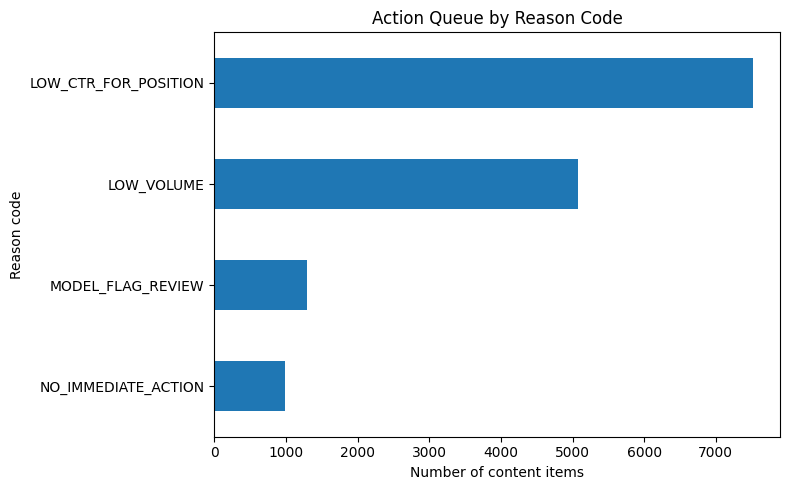

Figure exported to: work/figures/action_queue_reason_codes.png


In [9]:
# ============================================================
# REASON CODE DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

reason_counts = (
    action_queue["reason_code"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))

reason_counts.plot(
    kind="barh"
)

plt.xlabel("Number of content items")
plt.ylabel("Reason code")
plt.title("Action Queue by Reason Code")
plt.tight_layout()

reason_fig_path = figure_dir / "action_queue_reason_codes.png"

plt.savefig(
    reason_fig_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Figure exported to: {reason_fig_path}")

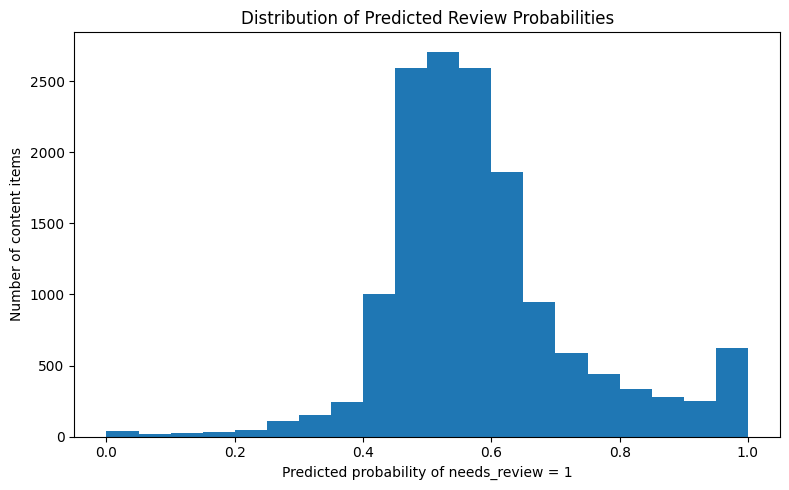

Figure exported to: work/figures/action_queue_probability.png


In [10]:
# ============================================================
# REVIEW PROBABILITY DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    action_queue["review_probability"],
    bins=20
)

plt.xlabel("Predicted probability of needs_review = 1")
plt.ylabel("Number of content items")
plt.title("Distribution of Predicted Review Probabilities")
plt.tight_layout()

prob_fig_path = figure_dir / "action_queue_probability.png"

plt.savefig(
    prob_fig_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Figure exported to: {prob_fig_path}")

## Self-check

Before you submit, confirm each line honestly:

- [ x] Every section above is filled — markdown thinking AND the code that backs it
- [x ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x ] No client names, URLs, or private queries anywhere
- [ x] My claims use careful words: observed, measured, directional, decision-support
- [x ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.